In [52]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms.v2 as transforms
import pandas as pd
import numpy as np
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

In [53]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

set_seed(SEED)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA
device = torch.device("cuda")

In [54]:
def calc_accuracy(predictions: np.ndarray, targets: np.ndarray, n_classes=50):
    assert len(predictions) == len(targets)
    accuracies = []
    for i in range(n_classes):
        accuracies.append((predictions[targets == i] == i).sum() / (targets == i).sum())
    return np.mean(accuracies)

In [55]:
base_transform = transforms.Compose(
    [
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ])

In [56]:
full_trainset = torchvision.datasets.ImageFolder("train/", transform=base_transform)

train_ratio = 0.95
num_classes = len(full_trainset.classes)

full_trainset_size = len(full_trainset)
train_size = int(train_ratio * full_trainset_size)
validation_size = full_trainset_size - train_size
trainset, valset = torch.utils.data.random_split(
    full_trainset, [train_size, validation_size]
)

In [57]:
print(f"Train size: {len(trainset)}, Validation size: {len(valset)}")

Train size: 83610, Validation size: 4401


In [58]:
temp_transform = transforms.Compose(
    [
        transforms.Resize(64),
    ]
)

In [ ]:
# all_samples = torch.stack([temp_transform(sample[0]) for sample in trainset])
# mean = all_samples.mean(axis=(0,2,3))
# std=all_samples.std(axis=(0,2,3))
# print(f"Data norm per channel: mean={mean} | std={std}")
# all_samples = None

Data norm per channel: mean=tensor([0.5206, 0.4952, 0.4383]) | std=tensor([0.2841, 0.2771, 0.2975])


In [ ]:
mean = torch.tensor([0.5206, 0.4952, 0.4383])
std = torch.tensor([0.2841, 0.2771, 0.2975])

In [61]:
class WrappedSubset:
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.classes = subset.dataset.classes
        self.targets = [subset.dataset.targets[i] for i in subset.indices]

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [62]:
train_transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.RandomCrop(64, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.TrivialAugmentWide(),
        transforms.Normalize(mean=mean, std=std),
        # transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), value="random"),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.Normalize(mean=mean, std=std),
    ]
)

trainset = WrappedSubset(trainset, transform=train_transform)
valset = WrappedSubset(valset, transform=test_transform)

In [63]:
batch_size = 128
shuffle = True
num_workers = 12
prefetch_factor = 4
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=shuffle,
    num_workers=num_workers,
    pin_memory=True,
    prefetch_factor=prefetch_factor,
    persistent_workers=True,
    drop_last=True,
    )
valloader = torch.utils.data.DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    prefetch_factor=prefetch_factor,
    persistent_workers=True,
    )

In [64]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.leaky_relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.leaky_relu(out)

class FinalNet(nn.Module):
    def __init__(self, num_classes=50):
        super().__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU()
        )
        
        self.layer1 = ResidualBlock(64, 64, stride=1)
        self.layer2 = ResidualBlock(64, 128, stride=2) # to 32x32
        self.layer3 = ResidualBlock(128, 256, stride=2) # to 16x16
        self.layer4 = ResidualBlock(256, 512, stride=2) # to 8x8
        # self.layer5 = ResidualBlock(512, 512, stride=1)
        
        self.dropout = nn.Dropout(0.3)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # x = self.layer5(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

In [65]:
import torch.optim as optim

set_seed(42)

num_classes = len(trainset.classes)
class_counts = torch.bincount(torch.tensor(trainset.targets), minlength=num_classes).float()
class_weights = class_counts.sum() / (num_classes * class_counts)
class_weights = class_weights / class_weights.mean()

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=0.1,
)

net = FinalNet(num_classes=num_classes).to(device)
net

FinalNet(
  (prep): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (layer1): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential()
  )
  (layer2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2

In [66]:
def validate(model, dataloader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return val_loss / len(dataloader), 100 * correct / total

In [67]:
optimizer = optim.AdamW(net.parameters(), lr=5e-3, weight_decay=1e-4)

In [68]:

num_of_epochs = 30
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.005, 
                                                steps_per_epoch=len(trainloader), 
                                                epochs=num_of_epochs)

In [69]:
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

net.train()
for epoch in range(num_of_epochs):

    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = net(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()

    val_loss, val_acc = validate(net, valloader, criterion, device)
    print("[%d/%d] loss: %.3f, val_loss: %.3f, val_acc: %d %%" % (epoch + 1, num_of_epochs, running_loss / len(trainloader), val_loss, val_acc))
    running_loss = 0.0
    net.train()

print("Finished Training")

[1/30] loss: 3.372, val_loss: 3.000, val_acc: 25 %
[2/30] loss: 3.081, val_loss: 2.786, val_acc: 32 %
[3/30] loss: 2.903, val_loss: 2.771, val_acc: 34 %
[4/30] loss: 2.760, val_loss: 2.835, val_acc: 34 %
[5/30] loss: 2.612, val_loss: 2.571, val_acc: 40 %
[6/30] loss: 2.473, val_loss: 2.283, val_acc: 50 %
[7/30] loss: 2.360, val_loss: 2.259, val_acc: 52 %
[8/30] loss: 2.261, val_loss: 2.050, val_acc: 59 %
[9/30] loss: 2.176, val_loss: 2.106, val_acc: 58 %
[10/30] loss: 2.107, val_loss: 1.914, val_acc: 63 %
[11/30] loss: 2.044, val_loss: 1.887, val_acc: 64 %
[12/30] loss: 1.996, val_loss: 1.855, val_acc: 65 %
[13/30] loss: 1.939, val_loss: 1.848, val_acc: 66 %
[14/30] loss: 1.898, val_loss: 1.824, val_acc: 67 %
[15/30] loss: 1.853, val_loss: 1.758, val_acc: 68 %
[16/30] loss: 1.814, val_loss: 1.697, val_acc: 71 %
[17/30] loss: 1.775, val_loss: 1.715, val_acc: 71 %
[18/30] loss: 1.732, val_loss: 1.647, val_acc: 73 %
[19/30] loss: 1.694, val_loss: 1.647, val_acc: 73 %
[20/30] loss: 1.657, 

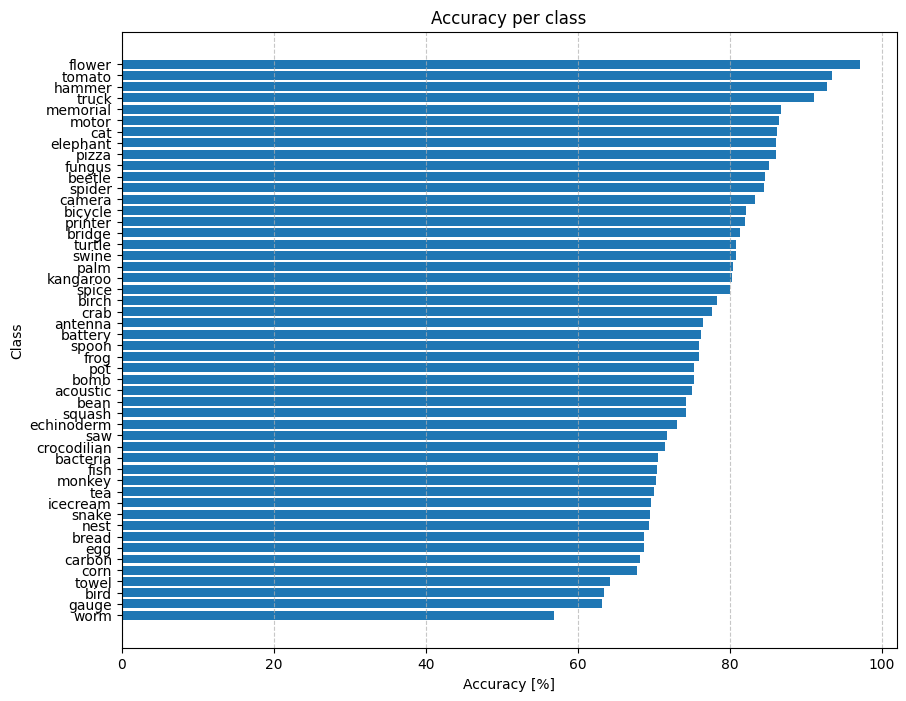

Accuracy val overall: 77.32 %
Mean class accuracy: 77.03 %


In [70]:
def per_class_accuracy(model, dataloader, device, class_names):
    model.eval()
    class_correct = torch.zeros(len(class_names), dtype=torch.long)
    class_total = torch.zeros(len(class_names), dtype=torch.long)

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(inputs)
            predicted = outputs.argmax(dim=1)
            matches = predicted == labels

            for class_idx in range(len(class_names)):
                class_mask = labels == class_idx
                class_total[class_idx] += class_mask.sum().item()
                class_correct[class_idx] += (matches & class_mask).sum().item()

    accuracies = 100.0 * class_correct.float() / class_total.float()
    return accuracies

val_loss, val_acc = validate(net, valloader, criterion, device)
class_accuracies = per_class_accuracy(net, valloader, device, valset.classes)
sorted_indices = torch.argsort(class_accuracies, descending=True)
sorted_class_names = [valset.classes[i] for i in sorted_indices.tolist()]
sorted_accuracies = class_accuracies[sorted_indices]

plt.figure(figsize=(10, 8))
plt.barh(sorted_class_names, sorted_accuracies.cpu().numpy())
plt.xlabel('Accuracy [%]')
plt.ylabel('Class')
plt.gca().invert_yaxis()
plt.title('Accuracy per class')
# plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Accuracy val overall: %.2f %%" % val_acc)
print("Mean class accuracy: %.2f %%" % class_accuracies.mean())

In [71]:
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in trainloader:
        inputs = inputs.to(device, non_blocking=True)
        outputs = net(inputs).cpu()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(
    "Accuracy train : %d %%" % (100 * correct / total)
)

Accuracy train : 81 %


In [72]:
# saving
PATH = "fin_net_v2.pth"

torch.save(net.state_dict(), PATH)
print(f"Model weights saved to {PATH}")

Model weights saved to fin_net_v2.pth


In [73]:
# loading
# PATH = "fin_net_v2.pth"

# net = FinalNet()
# net.load_state_dict(torch.load(PATH, map_location=device))
# net.to(device)
# net.eval()

In [74]:
from pathlib import Path
from PIL import Image

test_dir = Path("test")
image_paths = sorted(test_dir.iterdir())

net.eval()
pred_rows = []

with torch.no_grad():
    for image_path in image_paths:
        img = Image.open(image_path).convert("RGB")
        x = base_transform(img)
        x = test_transform(x)
        x = x.unsqueeze(0).to(device, non_blocking=True)

        logits = net(x)
        pred_class = int(logits.argmax(dim=1).item())
        pred_rows.append((image_path.name, pred_class))

preds_df = pd.DataFrame(pred_rows, columns=["filename", "label"])
preds_df.to_csv("preds.csv", index=False, header=False)

print(f"Saved {len(preds_df)} preds")
preds_df.head()

Saved 10000 preds


,filename,label
0,IMG_000134.JPEG,13
1,IMG_000227.JPEG,23
2,IMG_000240.JPEG,49
3,IMG_000241.JPEG,34
4,IMG_000242.JPEG,15
